# 04 — Evaluasi Final dan Ekspor Model

**Project:** NutriSmart AI  
**Kasus:** Klasifikasi biner risiko pola hidup terhadap obesitas

## Tujuan notebook

Notebook ini digunakan untuk:

1. Memuat pipeline kandidat hasil notebook 03.
2. Memuat data testing yang sejak awal disimpan terpisah.
3. Melakukan prediksi final satu kali pada data testing.
4. Menghitung metrik performa final.
5. Menampilkan confusion matrix, ROC curve, precision-recall curve, dan calibration curve.
6. Melakukan analisis threshold secara deskriptif.
7. Menampilkan feature importance atau coefficient.
8. Menyimpan model final menjadi `best_model_pipeline.joblib`.
9. Menyimpan metrics, metadata, prediksi test, dan feature importance.
10. Melakukan smoke test dengan memuat ulang file model final.

> Hasil model adalah skor berbasis pola data, bukan diagnosis medis dan bukan probabilitas klinis yang pasti.


## Konsep penting

### Mengapa data testing hanya digunakan sekarang?

Data testing disimpan sejak notebook 02 dan tidak digunakan untuk:

- memilih algoritma;
- membandingkan model;
- mencari hyperparameter.

Dengan demikian, evaluasi pada notebook ini lebih mendekati simulasi performa pada data baru.

### Threshold utama

Untuk klasifikasi final digunakan threshold default:

```text
0.50
```

Analisis threshold lain hanya bersifat deskriptif. Kita tidak mengubah threshold final berdasarkan data testing agar tidak melakukan tuning terhadap test set.

### Skor aplikasi

Aplikasi dapat menghitung:

```text
risk_score = model_probability × 100
```

Namun, skor tersebut harus disebut **skor model pola hidup**, bukan peluang klinis seseorang pasti mengalami obesitas.


In [1]:
from pathlib import Path
import json
import platform
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display

from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

DEFAULT_THRESHOLD = 0.50

print("Library berhasil dimuat.")
print(f"Python        : {sys.version.split()[0]}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"Platform      : {platform.platform()}")


Library berhasil dimuat.
Python        : 3.12.10
scikit-learn : 1.9.0
Platform      : Windows-11-10.0.26200-SP0


## 1. Menentukan lokasi project dan file yang dibutuhkan

Notebook membutuhkan:

- `data/processed/test_lifestyle_raw.csv`
- `artifacts/candidate_model_pipeline.joblib`
- `artifacts/model_experiment_summary.json`
- `artifacts/preprocessing_metadata.json`

Apabila file kandidat belum tersedia, jalankan notebook 03 sampai selesai.


In [2]:
TEST_FILENAME = "test_lifestyle_raw.csv"
CANDIDATE_MODEL_FILENAME = "candidate_model_pipeline.joblib"

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(
    (
        path for path in candidate_roots
        if (
            (path / "data" / "processed" / TEST_FILENAME).exists()
            and (path / "artifacts" / CANDIDATE_MODEL_FILENAME).exists()
        )
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "File testing atau candidate model tidak ditemukan. "
        "Pastikan notebook 02 dan 03 sudah dijalankan sampai selesai."
    )

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

TEST_PATH = PROCESSED_DATA_DIR / TEST_FILENAME
CANDIDATE_MODEL_PATH = ARTIFACTS_DIR / CANDIDATE_MODEL_FILENAME
EXPERIMENT_SUMMARY_PATH = ARTIFACTS_DIR / "model_experiment_summary.json"
PREPROCESSING_METADATA_PATH = ARTIFACTS_DIR / "preprocessing_metadata.json"

print(f"Project root          : {PROJECT_ROOT}")
print(f"Testing data          : {TEST_PATH}")
print(f"Candidate model       : {CANDIDATE_MODEL_PATH}")
print(f"Experiment summary    : {EXPERIMENT_SUMMARY_PATH}")
print(f"Preprocessing metadata: {PREPROCESSING_METADATA_PATH}")


Project root          : C:\Projects\nutrismart-ai
Testing data          : C:\Projects\nutrismart-ai\data\processed\test_lifestyle_raw.csv
Candidate model       : C:\Projects\nutrismart-ai\artifacts\candidate_model_pipeline.joblib
Experiment summary    : C:\Projects\nutrismart-ai\artifacts\model_experiment_summary.json
Preprocessing metadata: C:\Projects\nutrismart-ai\artifacts\preprocessing_metadata.json


## 2. Memuat data testing dan pipeline kandidat

Target:

```text
0 = Non-Obesity
1 = Obesity
```


In [3]:
test_data = pd.read_csv(TEST_PATH, index_col="source_index")

TARGET_COLUMN = "Obesity_Binary"

X_test = test_data.drop(columns=[TARGET_COLUMN]).copy()
y_test = test_data[TARGET_COLUMN].copy()

candidate_model = joblib.load(CANDIDATE_MODEL_PATH)

with open(EXPERIMENT_SUMMARY_PATH, "r", encoding="utf-8") as file:
    experiment_summary = json.load(file)

with open(PREPROCESSING_METADATA_PATH, "r", encoding="utf-8") as file:
    preprocessing_metadata = json.load(file)

print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")
print(f"Model type   : {type(candidate_model).__name__}")

display(X_test.head())


X_test shape : (418, 10)
y_test shape : (418,)
Model type   : Pipeline


,FCVC,NCP,CH2O,FAF,TUE,FAVC,CAEC,SCC,CALC,MTRANS
source_index,,,,,,,,,,
2035,3.0000,3.0000,2.4959,0.0000,0.2186,yes,Sometimes,no,Sometimes,Public_Transportation
1681,3.0000,2.2805,1.5916,0.9328,0.0000,yes,Sometimes,no,Sometimes,Public_Transportation
1234,1.0816,2.8707,1.1176,0.0000,1.6168,yes,Sometimes,no,Sometimes,Public_Transportation
2066,3.0000,3.0000,2.7223,0.0000,0.0917,yes,Sometimes,no,Sometimes,Public_Transportation
1055,2.6073,3.0000,2.0000,0.4510,0.6309,yes,Sometimes,no,Sometimes,Public_Transportation


## 3. Validasi struktur sebelum evaluasi

Notebook memastikan:

- jumlah baris fitur dan target sama;
- target hanya berisi 0 dan 1;
- urutan fitur sesuai metadata;
- tidak ada Height, Weight, BMI, atau target di dalam input model.


In [4]:
expected_features = preprocessing_metadata["main_features"]

forbidden_features = {
    "Height",
    "Weight",
    "BMI",
    "BMI_EDA",
    "NObeyesdad",
    "Obesity_Binary",
}

assert len(X_test) == len(y_test)
assert set(y_test.unique()).issubset({0, 1})
assert list(X_test.columns) == expected_features
assert not forbidden_features.intersection(X_test.columns)
assert X_test.isna().sum().sum() == 0

print("Validasi struktur berhasil.")
print("Urutan fitur:", list(X_test.columns))


Validasi struktur berhasil.
Urutan fitur: ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'FAVC', 'CAEC', 'SCC', 'CALC', 'MTRANS']


## 4. Melakukan prediksi final pada data testing

Prediksi dilakukan menggunakan:

- `predict()` untuk kelas 0/1;
- `predict_proba()` untuk skor probabilitas kelas Obesity.

Threshold default klasifikasi adalah 0,50.


In [5]:
y_probability = candidate_model.predict_proba(X_test)[:, 1]

y_prediction = (
    y_probability >= DEFAULT_THRESHOLD
).astype(int)

print("Prediksi final pada data testing berhasil.")
print(f"Jumlah prediksi : {len(y_prediction)}")
print(f"Threshold       : {DEFAULT_THRESHOLD:.2f}")


Prediksi final pada data testing berhasil.
Jumlah prediksi : 418
Threshold       : 0.50


## 5. Menghitung metrik final

Metrik:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Average Precision
- Brier Score

Untuk semua metrik kecuali Brier Score, nilai lebih tinggi umumnya lebih baik. Untuk Brier Score, nilai lebih rendah lebih baik karena mengukur kesalahan probabilitas.


In [6]:
test_metrics = {
    "threshold": DEFAULT_THRESHOLD,
    "accuracy": accuracy_score(y_test, y_prediction),
    "precision": precision_score(
        y_test,
        y_prediction,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        y_prediction,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_test,
        y_prediction,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        y_probability,
    ),
    "average_precision": average_precision_score(
        y_test,
        y_probability,
    ),
    "brier_score": brier_score_loss(
        y_test,
        y_probability,
    ),
}

display(pd.Series(test_metrics, name="value").to_frame())


,value
threshold,0.5000
accuracy,0.9067
precision,0.8939
recall,0.9077
f1_score,0.9008
roc_auc,0.9466
average_precision,0.9420
brier_score,0.0880


## 6. Classification report

Classification report menampilkan precision, recall, F1-score, dan support untuk setiap kelas.


In [7]:
class_names = ["Non-Obesity", "Obesity"]

report_dict = classification_report(
    y_test,
    y_prediction,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).T
display(report_df)


,precision,recall,f1-score,support
Non-Obesity,0.9182,0.9058,0.9120,223.0000
Obesity,0.8939,0.9077,0.9008,195.0000
accuracy,0.9067,0.9067,0.9067,0.9067
macro avg,0.9061,0.9068,0.9064,418.0000
weighted avg,0.9069,0.9067,0.9067,418.0000


## 7. Confusion matrix

Susunan confusion matrix:

```text
                Prediksi 0     Prediksi 1
Aktual 0        True Negative  False Positive
Aktual 1        False Negative True Positive
```

Untuk project skrining, false negative perlu diperhatikan karena merupakan data Obesity yang diprediksi Non-Obesity.


,component,count
0,True Negative,202
1,False Positive,21
2,False Negative,18
3,True Positive,177


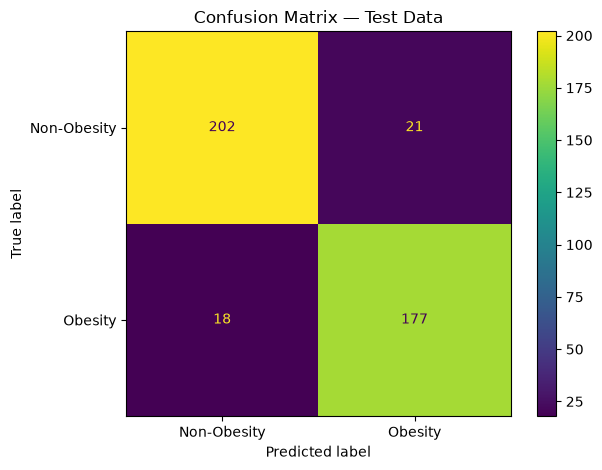

In [8]:
cm = confusion_matrix(
    y_test,
    y_prediction,
    labels=[0, 1],
)

tn, fp, fn, tp = cm.ravel()

confusion_summary = pd.DataFrame(
    {
        "component": [
            "True Negative",
            "False Positive",
            "False Negative",
            "True Positive",
        ],
        "count": [tn, fp, fn, tp],
    }
)

display(confusion_summary)

display_plot = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
)

display_plot.plot()
plt.title("Confusion Matrix — Test Data")
plt.tight_layout()
plt.show()


## 8. ROC curve

ROC curve memperlihatkan trade-off antara true positive rate dan false positive rate pada berbagai threshold.


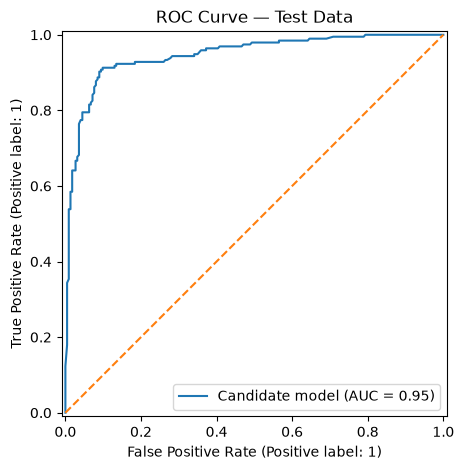

In [9]:
RocCurveDisplay.from_predictions(
    y_test,
    y_probability,
    name="Candidate model",
)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve — Test Data")
plt.tight_layout()
plt.show()


## 9. Precision-recall curve

Precision-recall curve sangat berguna untuk melihat hubungan antara kemampuan menemukan kelas Obesity dan ketepatan prediksi kelas tersebut.


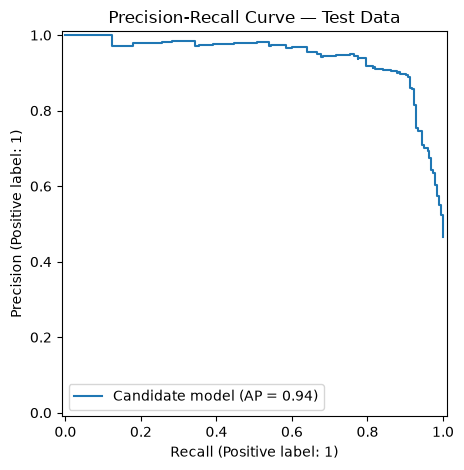

In [10]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probability,
    name="Candidate model",
)

plt.title("Precision-Recall Curve — Test Data")
plt.tight_layout()
plt.show()


## 10. Calibration curve

Calibration curve membandingkan probabilitas model dengan proporsi aktual kelas positif.

Jika kurva mendekati garis diagonal, probabilitas model lebih terkalibrasi. Jika jauh dari diagonal, skor masih dapat digunakan untuk ranking atau monitoring, tetapi tidak boleh dianggap probabilitas klinis yang tepat.


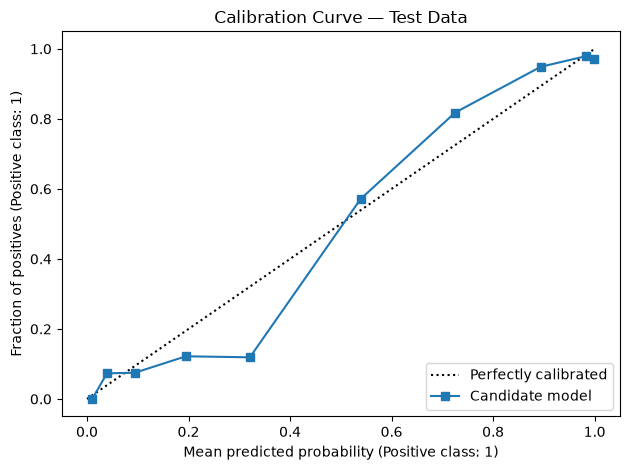

In [11]:
CalibrationDisplay.from_predictions(
    y_test,
    y_probability,
    n_bins=10,
    strategy="quantile",
    name="Candidate model",
)

plt.title("Calibration Curve — Test Data")
plt.tight_layout()
plt.show()


## 11. Analisis threshold secara deskriptif

Kita menampilkan performa pada beberapa threshold untuk memahami trade-off.

> Threshold final tetap 0,50. Tabel ini tidak digunakan untuk memilih threshold baru dari data testing.


In [12]:
threshold_values = np.arange(0.20, 0.85, 0.05)
threshold_rows = []

for threshold in threshold_values:
    threshold_prediction = (
        y_probability >= threshold
    ).astype(int)

    threshold_cm = confusion_matrix(
        y_test,
        threshold_prediction,
        labels=[0, 1],
    )

    threshold_tn, threshold_fp, threshold_fn, threshold_tp = (
        threshold_cm.ravel()
    )

    threshold_rows.append(
        {
            "threshold": threshold,
            "accuracy": accuracy_score(
                y_test,
                threshold_prediction,
            ),
            "precision": precision_score(
                y_test,
                threshold_prediction,
                zero_division=0,
            ),
            "recall": recall_score(
                y_test,
                threshold_prediction,
                zero_division=0,
            ),
            "f1_score": f1_score(
                y_test,
                threshold_prediction,
                zero_division=0,
            ),
            "false_positive": threshold_fp,
            "false_negative": threshold_fn,
        }
    )

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)


,threshold,accuracy,precision,recall,f1_score,false_positive,false_negative
0,0.2000,0.7823,0.6926,0.9590,0.8043,83,8
1,0.2500,0.8110,0.7302,0.9436,0.8233,68,11
2,0.3000,0.8397,0.7735,0.9282,0.8438,53,14
3,0.3500,0.8684,0.8153,0.9282,0.8681,41,14
4,0.4000,0.8900,0.8565,0.9179,0.8861,30,16
5,0.4500,0.8971,0.8725,0.9128,0.8922,26,17
6,0.5000,0.9067,0.8939,0.9077,0.9008,21,18
7,0.5500,0.8947,0.9037,0.8667,0.8848,18,26
8,0.6000,0.8804,0.9096,0.8256,0.8656,16,34
9,0.6500,0.8780,0.9337,0.7949,0.8587,11,40


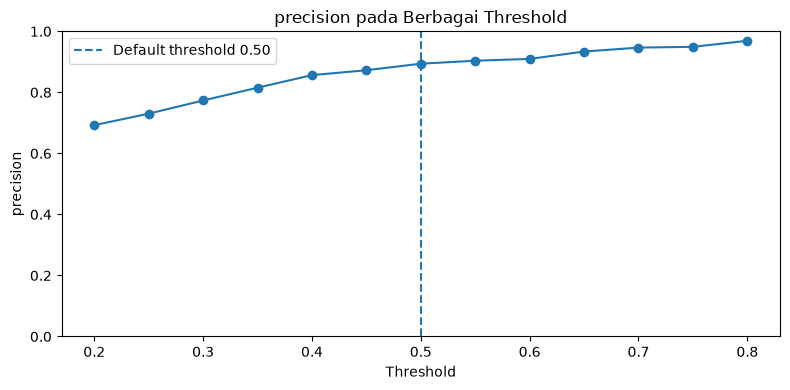

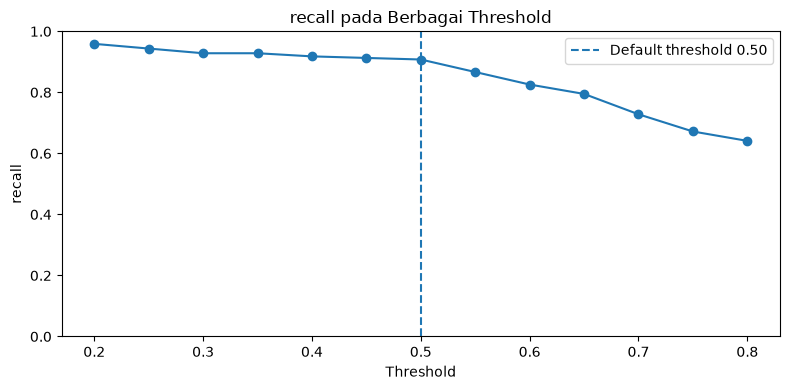

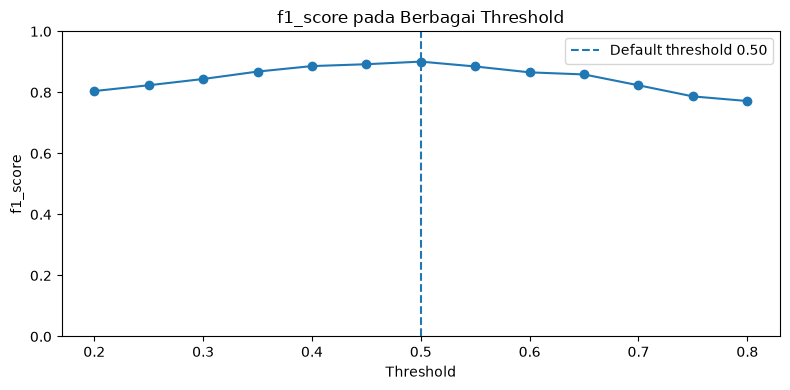

In [13]:
for metric in ["precision", "recall", "f1_score"]:
    plt.figure(figsize=(8, 4))
    plt.plot(
        threshold_table["threshold"],
        threshold_table[metric],
        marker="o",
    )
    plt.axvline(
        DEFAULT_THRESHOLD,
        linestyle="--",
        label="Default threshold 0.50",
    )
    plt.title(f"{metric} pada Berbagai Threshold")
    plt.xlabel("Threshold")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()


## 12. Distribusi skor probabilitas

Grafik ini membantu melihat apakah skor kelas Obesity dan Non-Obesity cukup terpisah.


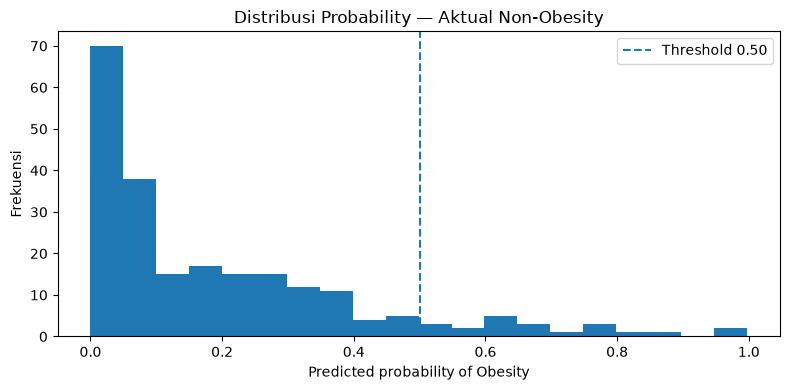

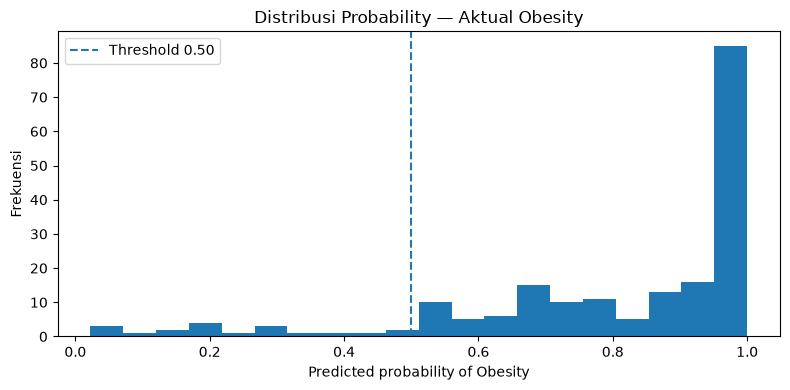

In [14]:
probability_by_class = pd.DataFrame(
    {
        "actual_class": y_test.map(
            {
                0: "Non-Obesity",
                1: "Obesity",
            }
        ),
        "obesity_probability": y_probability,
    }
)

for class_name in class_names:
    values = probability_by_class.loc[
        probability_by_class["actual_class"] == class_name,
        "obesity_probability",
    ]

    plt.figure(figsize=(8, 4))
    plt.hist(values, bins=20)
    plt.axvline(
        DEFAULT_THRESHOLD,
        linestyle="--",
        label="Threshold 0.50",
    )
    plt.title(f"Distribusi Probability — Aktual {class_name}")
    plt.xlabel("Predicted probability of Obesity")
    plt.ylabel("Frekuensi")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 13. Membuat tabel prediksi testing

File ini berguna untuk:

- audit;
- analisis kesalahan;
- melihat false positive dan false negative;
- dokumentasi laporan.


In [15]:
test_predictions = X_test.copy()
test_predictions["actual_target"] = y_test
test_predictions["predicted_target"] = y_prediction
test_predictions["obesity_probability"] = y_probability
test_predictions["risk_score"] = (
    test_predictions["obesity_probability"] * 100
).round(2)
test_predictions["is_correct"] = (
    test_predictions["actual_target"]
    == test_predictions["predicted_target"]
)

def error_type(row):
    if row["actual_target"] == 0 and row["predicted_target"] == 0:
        return "True Negative"
    if row["actual_target"] == 0 and row["predicted_target"] == 1:
        return "False Positive"
    if row["actual_target"] == 1 and row["predicted_target"] == 0:
        return "False Negative"
    return "True Positive"

test_predictions["prediction_type"] = test_predictions.apply(
    error_type,
    axis=1,
)

display(test_predictions.head())


,FCVC,NCP,CH2O,FAF,TUE,FAVC,CAEC,SCC,CALC,MTRANS,actual_target,predicted_target,obesity_probability,risk_score,is_correct,prediction_type
source_index,,,,,,,,,,,,,,,,
2035,3.0000,3.0000,2.4959,0.0000,0.2186,yes,Sometimes,no,Sometimes,Public_Transportation,1,1,1.0000,100.0000,True,True Positive
1681,3.0000,2.2805,1.5916,0.9328,0.0000,yes,Sometimes,no,Sometimes,Public_Transportation,1,1,0.9525,95.2500,True,True Positive
1234,1.0816,2.8707,1.1176,0.0000,1.6168,yes,Sometimes,no,Sometimes,Public_Transportation,1,0,0.2700,27.0000,False,False Negative
2066,3.0000,3.0000,2.7223,0.0000,0.0917,yes,Sometimes,no,Sometimes,Public_Transportation,1,1,0.9950,99.5000,True,True Positive
1055,2.6073,3.0000,2.0000,0.4510,0.6309,yes,Sometimes,no,Sometimes,Public_Transportation,0,1,0.6687,66.8800,False,False Positive


## 14. Analisis kesalahan

Bagian ini menampilkan contoh false positive dan false negative.

- **False positive:** pola hidup diprediksi Obesity tetapi target aktual Non-Obesity.
- **False negative:** pola hidup diprediksi Non-Obesity tetapi target aktual Obesity.


In [16]:
false_positive_examples = test_predictions[
    test_predictions["prediction_type"] == "False Positive"
].sort_values(
    "obesity_probability",
    ascending=False,
)

false_negative_examples = test_predictions[
    test_predictions["prediction_type"] == "False Negative"
].sort_values(
    "obesity_probability",
    ascending=True,
)

print("Contoh False Positive:")
display(false_positive_examples.head(10))

print("Contoh False Negative:")
display(false_negative_examples.head(10))


Contoh False Positive:


,FCVC,NCP,CH2O,FAF,TUE,FAVC,CAEC,SCC,CALC,MTRANS,actual_target,predicted_target,obesity_probability,risk_score,is_correct,prediction_type
source_index,,,,,,,,,,,,,,,,
753,3.0000,3.0000,2.2292,1.6080,0.6281,yes,Sometimes,no,Sometimes,Public_Transportation,0,1,0.9975,99.7500,False,False Positive
818,3.0000,3.0000,2.7592,1.7633,0.4533,yes,Sometimes,no,Sometimes,Public_Transportation,0,1,0.9775,97.7500,False,False Positive
1096,2.9922,3.0000,2.4138,0.4582,0.6883,yes,Sometimes,no,Sometimes,Public_Transportation,0,1,0.8775,87.7500,False,False Positive
933,2.4872,3.0000,2.3970,0.5771,0.4351,yes,Sometimes,no,Sometimes,Automobile,0,1,0.8475,84.7500,False,False Positive
948,2.0000,1.8938,3.0000,1.3762,1.8013,yes,Sometimes,no,no,Public_Transportation,0,1,0.7975,79.7500,False,False Positive
281,2.0000,3.0000,3.0000,3.0000,0.0000,yes,Sometimes,no,no,Public_Transportation,0,1,0.7900,79.0000,False,False Positive
1091,2.8825,3.0000,2.4530,1.0000,0.7467,yes,Sometimes,no,Sometimes,Public_Transportation,0,1,0.7550,75.5000,False,False Positive
222,3.0000,3.0000,3.0000,0.0000,0.0000,no,Sometimes,no,no,Automobile,0,1,0.7375,73.7500,False,False Positive
838,2.6210,3.0000,2.8246,0.7546,2.0000,yes,Sometimes,no,Sometimes,Public_Transportation,0,1,0.6700,67.0000,False,False Positive


Contoh False Negative:


,FCVC,NCP,CH2O,FAF,TUE,FAVC,CAEC,SCC,CALC,MTRANS,actual_target,predicted_target,obesity_probability,risk_score,is_correct,prediction_type
source_index,,,,,,,,,,,,,,,,
201,2.0000,3.0000,2.0000,2.0000,0.0000,yes,Frequently,no,no,Public_Transportation,1,0,0.0225,2.2500,False,False Negative
189,3.0000,3.0000,3.0000,3.0000,0.0000,yes,Frequently,no,no,Public_Transportation,1,0,0.0400,4.0000,False,False Negative
145,3.0000,3.0000,1.0000,0.0000,0.0000,no,Sometimes,no,Sometimes,Automobile,1,0,0.0575,5.7500,False,False Negative
376,2.0000,3.0000,2.0000,0.0000,1.0000,no,Sometimes,no,Sometimes,Automobile,1,0,0.0807,8.0700,False,False Negative
1519,2.0000,3.0000,2.0000,1.3992,1.0000,yes,Sometimes,no,Sometimes,Public_Transportation,1,0,0.1250,12.5000,False,False Negative
381,2.0000,3.0000,3.0000,1.0000,0.0000,no,Sometimes,no,no,Public_Transportation,1,0,0.1375,13.7500,False,False Negative
1316,2.0000,3.0000,2.7452,0.0000,0.8090,yes,Sometimes,no,Sometimes,Public_Transportation,1,0,0.1750,17.5000,False,False Negative
68,1.0000,3.0000,2.0000,0.0000,0.0000,yes,no,yes,Frequently,Automobile,1,0,0.1948,19.4800,False,False Negative
411,3.0000,3.0000,2.0000,2.0000,0.0000,yes,Sometimes,no,Sometimes,Public_Transportation,1,0,0.2075,20.7500,False,False Negative


## 15. Mengambil feature importance atau coefficient

Kode dibuat fleksibel:

- model berbasis tree menggunakan `feature_importances_`;
- Logistic Regression menggunakan `coef_`.

Nilai ini menunjukkan kontribusi relatif pada model, bukan hubungan sebab-akibat.


In [17]:
preprocessor = candidate_model.named_steps["preprocessor"]
estimator = candidate_model.named_steps["model"]

transformed_feature_names = (
    preprocessor.get_feature_names_out()
)

if hasattr(estimator, "feature_importances_"):
    importance_values = estimator.feature_importances_
    importance_kind = "feature_importance"
elif hasattr(estimator, "coef_"):
    importance_values = estimator.coef_[0]
    importance_kind = "coefficient"
else:
    importance_values = None
    importance_kind = None

if importance_values is not None:
    feature_importance = pd.DataFrame(
        {
            "feature": transformed_feature_names,
            "importance": importance_values,
        }
    )

    feature_importance["absolute_importance"] = (
        feature_importance["importance"].abs()
    )

    feature_importance = feature_importance.sort_values(
        "absolute_importance",
        ascending=False,
    ).reset_index(drop=True)

    print(f"Jenis interpretasi: {importance_kind}")
    display(feature_importance.head(20))
else:
    feature_importance = pd.DataFrame(
        columns=[
            "feature",
            "importance",
            "absolute_importance",
        ]
    )
    print(
        "Estimator tidak menyediakan feature_importances_ "
        "atau coef_."
    )


Jenis interpretasi: feature_importance


,feature,importance,absolute_importance
0,CH2O,0.1516,0.1516
1,FAF,0.1418,0.1418
2,NCP,0.1359,0.1359
3,FCVC,0.1346,0.1346
4,TUE,0.1251,0.1251
5,CAEC_Sometimes,0.0675,0.0675
6,CAEC_Frequently,0.0390,0.0390
7,FAVC_yes,0.0327,0.0327
8,FAVC_no,0.0322,0.0322
9,MTRANS_Public_Transportation,0.0251,0.0251


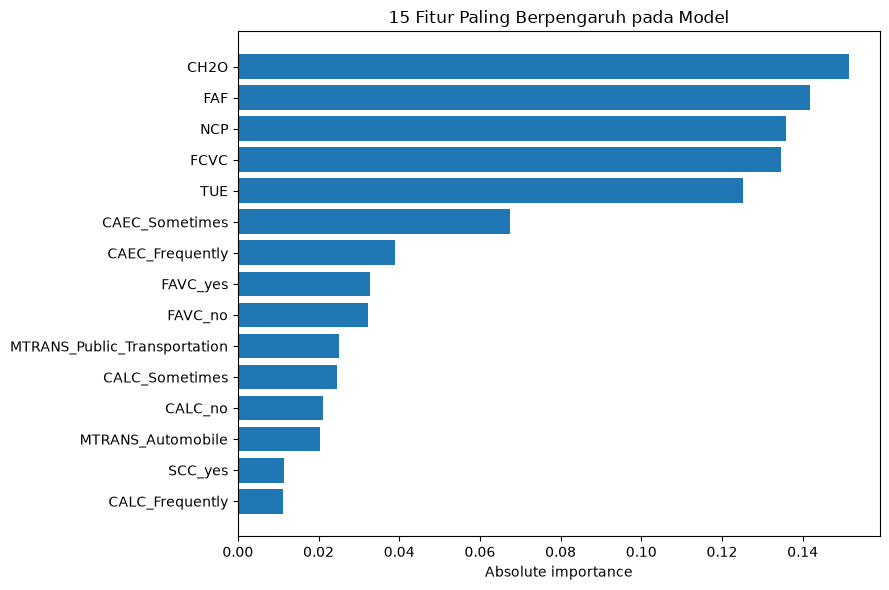

In [18]:
if not feature_importance.empty:
    top_features = feature_importance.head(15).sort_values(
        "absolute_importance"
    )

    plt.figure(figsize=(9, 6))
    plt.barh(
        top_features["feature"],
        top_features["absolute_importance"],
    )
    plt.title("15 Fitur Paling Berpengaruh pada Model")
    plt.xlabel("Absolute importance")
    plt.tight_layout()
    plt.show()


## 16. Menetapkan kategori skor untuk tampilan aplikasi

Untuk tahap prototype, skor ditampilkan dengan tiga label:

- `0–39.99` → Rendah
- `40–69.99` → Sedang
- `70–100` → Tinggi

Batas ini adalah kategori komunikasi aplikasi, bukan batas klinis.

Klasifikasi biner model tetap menggunakan threshold 0,50.


In [19]:
def classify_display_score(score):
    if score < 40:
        return "Rendah"
    if score < 70:
        return "Sedang"
    return "Tinggi"


test_predictions["display_risk_category"] = (
    test_predictions["risk_score"].apply(
        classify_display_score
    )
)

display(
    test_predictions[
        [
            "obesity_probability",
            "risk_score",
            "display_risk_category",
            "actual_target",
            "predicted_target",
        ]
    ].head(10)
)


,obesity_probability,risk_score,display_risk_category,actual_target,predicted_target
source_index,,,,,
2035,1.0000,100.0000,Tinggi,1,1
1681,0.9525,95.2500,Tinggi,1,1
1234,0.2700,27.0000,Rendah,1,0
2066,0.9950,99.5000,Tinggi,1,1
1055,0.6687,66.8800,Sedang,0,1
1744,0.9825,98.2500,Tinggi,1,1
1296,0.6300,63.0000,Sedang,1,1
95,0.0175,1.7500,Rendah,0,0
1442,0.6900,69.0000,Sedang,1,1


## 17. Keputusan ekspor model final

Pipeline kandidat diekspor sebagai model final apabila:

- dapat menghasilkan prediksi tanpa error;
- metrik final berhasil dihitung;
- ROC-AUC lebih besar daripada 0,50;
- file pipeline dapat dimuat ulang;
- seluruh fitur sesuai dengan metadata.

Keputusan ekspor tidak berarti model tervalidasi secara klinis.


In [20]:
export_checks = {
    "prediction_count_matches": (
        len(y_prediction) == len(y_test)
    ),
    "probability_count_matches": (
        len(y_probability) == len(y_test)
    ),
    "probability_range_valid": bool(
        np.all(
            (y_probability >= 0)
            & (y_probability <= 1)
        )
    ),
    "roc_auc_above_random": (
        test_metrics["roc_auc"] > 0.50
    ),
    "feature_order_matches": (
        list(X_test.columns) == expected_features
    ),
}

display(pd.Series(export_checks, name="passed").to_frame())

if not all(export_checks.values()):
    raise RuntimeError(
        "Model belum memenuhi pemeriksaan teknis ekspor."
    )

print("Seluruh pemeriksaan teknis ekspor berhasil.")


,passed
prediction_count_matches,True
probability_count_matches,True
probability_range_valid,True
roc_auc_above_random,True
feature_order_matches,True


Seluruh pemeriksaan teknis ekspor berhasil.


## 18. Menyimpan model final dan artifact evaluasi

File hasil:

- `best_model_pipeline.joblib`
- `model_metrics.json`
- `model_metadata.json`
- `test_predictions.csv`
- `feature_importance.csv`
- `threshold_analysis.csv`
- `classification_report.csv`


In [21]:
BEST_MODEL_PATH = ARTIFACTS_DIR / "best_model_pipeline.joblib"
METRICS_PATH = ARTIFACTS_DIR / "model_metrics.json"
MODEL_METADATA_PATH = ARTIFACTS_DIR / "model_metadata.json"
TEST_PREDICTIONS_PATH = ARTIFACTS_DIR / "test_predictions.csv"
FEATURE_IMPORTANCE_PATH = ARTIFACTS_DIR / "feature_importance.csv"
THRESHOLD_ANALYSIS_PATH = ARTIFACTS_DIR / "threshold_analysis.csv"
CLASSIFICATION_REPORT_PATH = ARTIFACTS_DIR / "classification_report.csv"

joblib.dump(candidate_model, BEST_MODEL_PATH)

test_predictions.to_csv(
    TEST_PREDICTIONS_PATH,
    index=True,
    index_label="source_index",
)

feature_importance.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False,
)

threshold_table.to_csv(
    THRESHOLD_ANALYSIS_PATH,
    index=False,
)

report_df.to_csv(
    CLASSIFICATION_REPORT_PATH,
)

metrics_payload = {
    "dataset_split": "held-out test set",
    "test_rows": int(len(X_test)),
    "default_threshold": DEFAULT_THRESHOLD,
    "positive_class": {
        "value": 1,
        "label": "Obesity",
    },
    "confusion_matrix": {
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
    },
    **{
        key: float(value)
        for key, value in test_metrics.items()
    },
}

with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(
        metrics_payload,
        file,
        indent=2,
        ensure_ascii=False,
    )

model_metadata = {
    "project": "NutriSmart AI",
    "model_purpose": (
        "Lifestyle-based obesity risk screening"
    ),
    "model_name": type(estimator).__name__,
    "pipeline_type": type(candidate_model).__name__,
    "model_source_file": CANDIDATE_MODEL_PATH.name,
    "final_model_file": BEST_MODEL_PATH.name,
    "features": expected_features,
    "numeric_features": preprocessing_metadata[
        "numeric_features"
    ],
    "categorical_features": preprocessing_metadata[
        "categorical_features"
    ],
    "target": {
        "name": TARGET_COLUMN,
        "mapping": {
            "0": "Non-Obesity",
            "1": "Obesity",
        },
    },
    "classification_threshold": DEFAULT_THRESHOLD,
    "display_score_formula": (
        "predict_proba(class=1) * 100"
    ),
    "display_risk_bands": {
        "low": "0 <= score < 40",
        "medium": "40 <= score < 70",
        "high": "70 <= score <= 100",
    },
    "best_parameters": experiment_summary.get(
        "best_parameters",
        {},
    ),
    "test_metrics_file": METRICS_PATH.name,
    "python_version": sys.version.split()[0],
    "scikit_learn_version": sklearn.__version__,
    "limitations": [
        "Hasil bukan diagnosis medis.",
        "Skor bukan probabilitas klinis yang pasti.",
        "Dataset bukan populasi Indonesia.",
        "Sebagian besar dataset bersifat sintetik.",
        "Model tidak memprediksi kepastian penurunan berat badan.",
    ],
}

with open(
    MODEL_METADATA_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        model_metadata,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(f"Model final           : {BEST_MODEL_PATH}")
print(f"Metrics               : {METRICS_PATH}")
print(f"Model metadata        : {MODEL_METADATA_PATH}")
print(f"Test predictions      : {TEST_PREDICTIONS_PATH}")
print(f"Feature importance    : {FEATURE_IMPORTANCE_PATH}")
print(f"Threshold analysis    : {THRESHOLD_ANALYSIS_PATH}")
print(f"Classification report : {CLASSIFICATION_REPORT_PATH}")


Model final           : C:\Projects\nutrismart-ai\artifacts\best_model_pipeline.joblib
Metrics               : C:\Projects\nutrismart-ai\artifacts\model_metrics.json
Model metadata        : C:\Projects\nutrismart-ai\artifacts\model_metadata.json
Test predictions      : C:\Projects\nutrismart-ai\artifacts\test_predictions.csv
Feature importance    : C:\Projects\nutrismart-ai\artifacts\feature_importance.csv
Threshold analysis    : C:\Projects\nutrismart-ai\artifacts\threshold_analysis.csv
Classification report : C:\Projects\nutrismart-ai\artifacts\classification_report.csv


## 19. Smoke test: memuat ulang model final

Smoke test memastikan:

- file tidak rusak;
- model dapat dimuat;
- model menghasilkan prediksi yang sama;
- probabilitas tetap sama setelah disimpan.


In [22]:
reloaded_model = joblib.load(BEST_MODEL_PATH)

sample_input = X_test.head(5)

original_prediction = candidate_model.predict(
    sample_input
)

reloaded_prediction = reloaded_model.predict(
    sample_input
)

original_probability = candidate_model.predict_proba(
    sample_input
)[:, 1]

reloaded_probability = reloaded_model.predict_proba(
    sample_input
)[:, 1]

assert np.array_equal(
    original_prediction,
    reloaded_prediction,
)

assert np.allclose(
    original_probability,
    reloaded_probability,
)

print("Smoke test berhasil.")
print("Model final dapat dimuat ulang dengan hasil konsisten.")


Smoke test berhasil.
Model final dapat dimuat ulang dengan hasil konsisten.


## 20. Contoh format input untuk Streamlit

Pipeline menerima DataFrame dengan satu baris dan urutan fitur yang sama seperti saat training.

Nilai berikut hanya contoh teknis untuk memastikan format input.


In [23]:
example_user_input = pd.DataFrame(
    [
        {
            "FCVC": 2.0,
            "NCP": 3.0,
            "CH2O": 2.0,
            "FAF": 1.0,
            "TUE": 1.0,
            "FAVC": "yes",
            "CAEC": "Sometimes",
            "SCC": "no",
            "CALC": "Sometimes",
            "MTRANS": "Public_Transportation",
        }
    ],
    columns=expected_features,
)

example_probability = reloaded_model.predict_proba(
    example_user_input
)[0, 1]

example_score = float(
    example_probability * 100
)

example_result = {
    "obesity_probability": example_probability,
    "risk_score": example_score,
    "display_category": classify_display_score(
        example_score
    ),
}

display(example_user_input)
display(pd.Series(example_result, name="value").to_frame())


,FCVC,NCP,CH2O,FAF,TUE,FAVC,CAEC,SCC,CALC,MTRANS
0,2.0000,3.0000,2.0000,1.0000,1.0000,yes,Sometimes,no,Sometimes,Public_Transportation


,value
obesity_probability,0.0025
risk_score,0.2500
display_category,Rendah


## 21. Ringkasan hasil akhir

Setelah notebook ini selesai:

1. Model kandidat telah diuji menggunakan data testing satu kali.
2. Metrik final telah dihitung.
3. Confusion matrix telah dianalisis.
4. ROC curve, precision-recall curve, dan calibration curve telah dibuat.
5. Threshold lain telah dianalisis secara deskriptif.
6. Kesalahan false positive dan false negative telah diperiksa.
7. Feature importance atau coefficient telah diekstrak.
8. Model final telah disimpan sebagai `best_model_pipeline.joblib`.
9. Model telah dimuat ulang melalui smoke test.
10. Format input untuk Streamlit telah diuji.

## Batas interpretasi

- Model mengukur kemiripan pola hidup dengan pola pada kelas obesitas dalam dataset.
- Skor bukan diagnosis dan bukan kepastian seseorang akan menjadi obesitas.
- Skor rendah pada pengguna yang BMI-nya obesitas berarti pola hidup yang dicatat relatif lebih mendukung pengendalian berat badan, bukan berarti pengguna tidak lagi obesitas.


## Checklist

- [ ] Seluruh cell berjalan tanpa error.
- [ ] Data testing hanya digunakan pada notebook ini.
- [ ] Accuracy, precision, recall, F1, dan ROC-AUC muncul.
- [ ] Confusion matrix berhasil dibuat.
- [ ] ROC curve berhasil dibuat.
- [ ] Precision-recall curve berhasil dibuat.
- [ ] Calibration curve berhasil dibuat.
- [ ] Threshold table berhasil dibuat.
- [ ] Feature importance atau coefficient berhasil dibuat.
- [ ] `best_model_pipeline.joblib` tersimpan.
- [ ] `model_metrics.json` tersimpan.
- [ ] `model_metadata.json` tersimpan.
- [ ] Smoke test berhasil.
- [ ] Notebook disimpan dan di-commit ke Git.
